In [1]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import seaborn as sns
df = pd.read_csv("hospital_insights_summary.csv")
print(df.head())

   week           service  patients_admitted   avg_stay  avg_satisfaction  \
0     1               ICU                  7   5.428571         84.857143   
1     1         emergency                  4   9.250000         86.000000   
2     1  general_medicine                  5   7.400000         77.400000   
3     1           surgery                  6  10.000000         84.666667   
4     2               ICU                  4   8.000000         69.250000   

   max_occupancy  staff_count  recommended_staff  
0             14           34                2.0  
1             13           39                1.0  
2             12           28                1.0  
3             11           25                2.0  
4             13           34                1.0  


In [2]:
print(df.isnull().sum())

week                 0
service              0
patients_admitted    0
avg_stay             0
avg_satisfaction     0
max_occupancy        0
staff_count          0
recommended_staff    0
dtype: int64


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               208 non-null    int64  
 1   service            208 non-null    object 
 2   patients_admitted  208 non-null    int64  
 3   avg_stay           208 non-null    float64
 4   avg_satisfaction   208 non-null    float64
 5   max_occupancy      208 non-null    int64  
 6   staff_count        208 non-null    int64  
 7   recommended_staff  208 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 13.1+ KB
None


In [4]:
print(df.describe())

             week  patients_admitted    avg_stay  avg_satisfaction  \
count  208.000000         208.000000  208.000000        208.000000   
mean    26.500000           4.807692    7.494813         79.429424   
std     15.044539           2.113115    2.207160          5.987425   
min      1.000000           1.000000    2.000000         60.000000   
25%     13.750000           3.000000    6.000000         75.650000   
50%     26.500000           5.000000    7.500000         79.514286   
75%     39.250000           6.000000    8.750000         83.500000   
max     52.000000          10.000000   14.000000         96.500000   

       max_occupancy  staff_count  recommended_staff  
count     208.000000   208.000000         208.000000  
mean       11.427885    31.500000           1.326923  
std         2.656610     5.421375           0.470221  
min         3.000000    25.000000           1.000000  
25%        10.000000    27.250000           1.000000  
50%        12.000000    31.000000      

In [5]:
df['service'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 208 entries, 0 to 207
Series name: service
Non-Null Count  Dtype 
--------------  ----- 
208 non-null    object
dtypes: object(1)
memory usage: 1.8+ KB


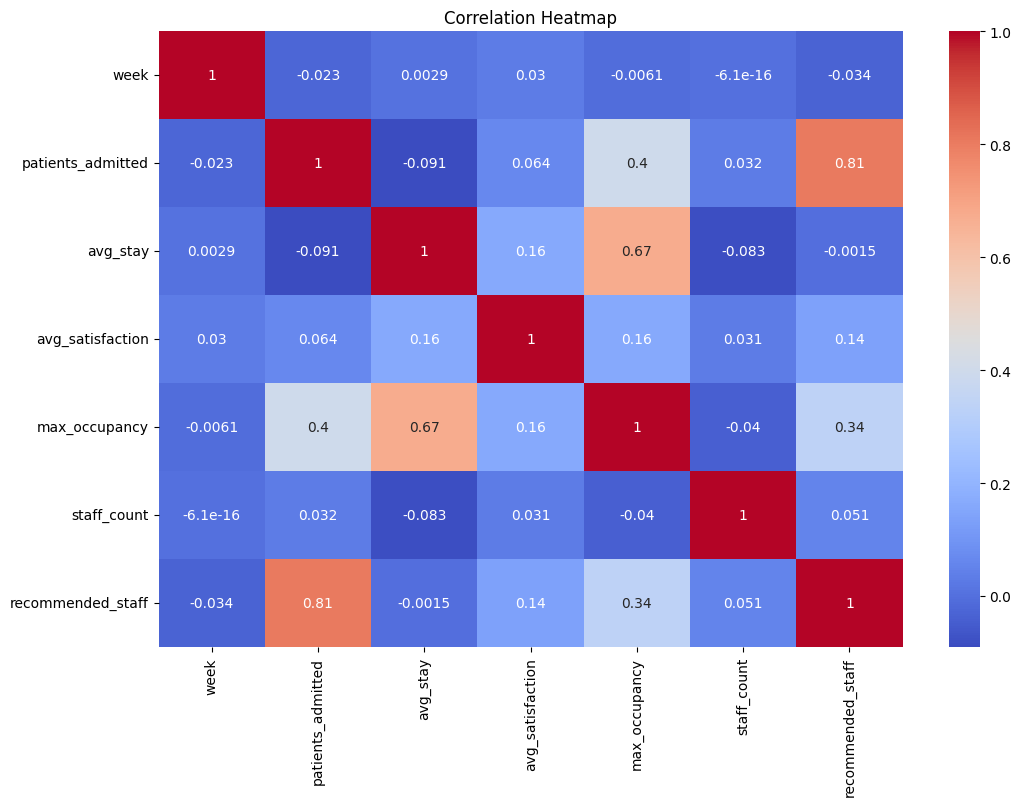

In [6]:
#Exploratory data analysis

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

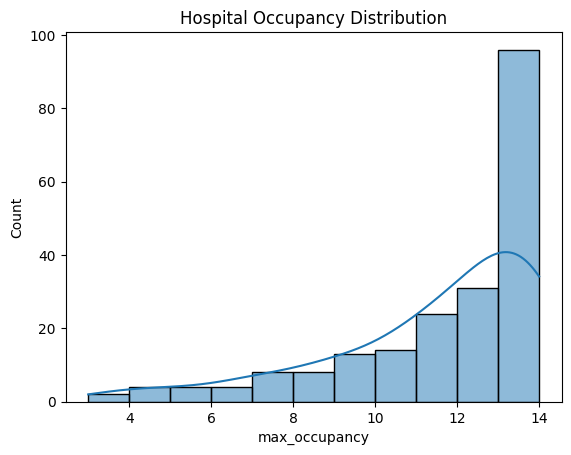

In [7]:
sns.histplot(
    df["max_occupancy"],
    kde=True
)

plt.title("Hospital Occupancy Distribution")

plt.show()

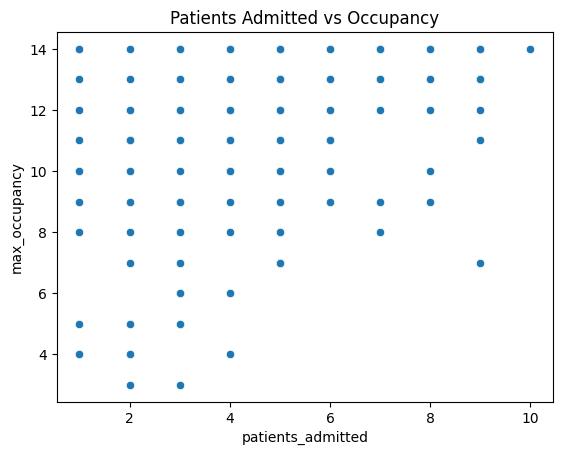

In [8]:
sns.scatterplot(
    x=df["patients_admitted"],
    y=df["max_occupancy"]
)

plt.title("Patients Admitted vs Occupancy")

plt.show()

In [9]:
#Feature Engineering 
df["recommended_staff"] = df["recommended_staff"].astype(int)

In [10]:
# df["staff_gap"] = (
#     df["recommended_staff"] - df["staff_count"]
# )

In [11]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff
0,1,ICU,7,5.428571,84.857143,14,34,2
1,1,emergency,4,9.250000,86.000000,13,39,1
2,1,general_medicine,5,7.400000,77.400000,12,28,1
3,1,surgery,6,10.000000,84.666667,11,25,2
4,2,ICU,4,8.000000,69.250000,13,34,1


In [12]:
df['recommended_staff']

0      2
1      1
2      1
3      2
4      1
      ..
203    1
204    2
205    1
206    1
207    1
Name: recommended_staff, Length: 208, dtype: int64

In [13]:
df["staff_sufficiency"] = (
    df["staff_count"] >= df["recommended_staff"]
).astype(int)
#1 - sufficient staff
#0 - insufficient staff

In [14]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency
0,1,ICU,7,5.428571,84.857143,14,34,2,1
1,1,emergency,4,9.250000,86.000000,13,39,1,1
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1
3,1,surgery,6,10.000000,84.666667,11,25,2,1
4,2,ICU,4,8.000000,69.250000,13,34,1,1


In [15]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency
0,1,ICU,7,5.428571,84.857143,14,34,2,1
1,1,emergency,4,9.250000,86.000000,13,39,1,1
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1
3,1,surgery,6,10.000000,84.666667,11,25,2,1
4,2,ICU,4,8.000000,69.250000,13,34,1,1


In [16]:
df["occupancy_pressure"] = (
    df["max_occupancy"] / 100
)

In [17]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure
0,1,ICU,7,5.428571,84.857143,14,34,2,1,0.14
1,1,emergency,4,9.250000,86.000000,13,39,1,1,0.13
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1,0.12
3,1,surgery,6,10.000000,84.666667,11,25,2,1,0.11
4,2,ICU,4,8.000000,69.250000,13,34,1,1,0.13


In [18]:
df["patients_per_staff"] = (
    df["patients_admitted"] / df["staff_count"]
)

In [19]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff
0,1,ICU,7,5.428571,84.857143,14,34,2,1,0.14,0.205882
1,1,emergency,4,9.250000,86.000000,13,39,1,1,0.13,0.102564
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1,0.12,0.178571
3,1,surgery,6,10.000000,84.666667,11,25,2,1,0.11,0.240000
4,2,ICU,4,8.000000,69.250000,13,34,1,1,0.13,0.117647


In [20]:
df["care_pressure"] = (
    df["avg_stay"] * df["occupancy_pressure"]
)

In [21]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure
0,1,ICU,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600
1,1,emergency,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880
3,1,surgery,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000
4,2,ICU,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400


In [22]:
df["satisfaction_risk"] = (
    10 - df["avg_satisfaction"]
)

In [23]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure,satisfaction_risk
0,1,ICU,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600,-74.857143
1,1,emergency,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025,-76.000000
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880,-67.400000
3,1,surgery,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000,-74.666667
4,2,ICU,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400,-59.250000


In [24]:
df["resource_shortage"] = (
    (df["staff_sufficiency"] == 0) |
    (df["occupancy_pressure"] > 0.85)
).astype(int)

In [25]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure,satisfaction_risk,resource_shortage
0,1,ICU,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600,-74.857143,0
1,1,emergency,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025,-76.000000,0
2,1,general_medicine,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880,-67.400000,0
3,1,surgery,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000,-74.666667,0
4,2,ICU,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400,-59.250000,0


In [26]:
print(df["resource_shortage"].value_counts())

resource_shortage
0    208
Name: count, dtype: int64


In [27]:
#Encoding Categorical Data
df = pd.get_dummies(df, columns=["service"], drop_first=True)

In [28]:
df.head()

,week,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure,satisfaction_risk,resource_shortage,service_emergency,service_general_medicine,service_surgery
0,1,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600,-74.857143,0,False,False,False
1,1,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025,-76.000000,0,True,False,False
2,1,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880,-67.400000,0,False,True,False
3,1,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000,-74.666667,0,False,False,True
4,2,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400,-59.250000,0,False,False,False


In [29]:
df["service_emergency"] = df["service_emergency"].astype(int)
#0 - False
#1- True

In [30]:
df.head()

,week,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure,satisfaction_risk,resource_shortage,service_emergency,service_general_medicine,service_surgery
0,1,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600,-74.857143,0,0,False,False
1,1,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025,-76.000000,0,1,False,False
2,1,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880,-67.400000,0,0,True,False
3,1,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000,-74.666667,0,0,False,True
4,2,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400,-59.250000,0,0,False,False


In [31]:
df["service_general_medicine"] = df["service_general_medicine"].astype(int)
df["service_surgery"] = df["service_surgery"].astype(int)

In [32]:
df.head()

,week,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_sufficiency,occupancy_pressure,patients_per_staff,care_pressure,satisfaction_risk,resource_shortage,service_emergency,service_general_medicine,service_surgery
0,1,7,5.428571,84.857143,14,34,2,1,0.14,0.205882,0.7600,-74.857143,0,0,0,0
1,1,4,9.250000,86.000000,13,39,1,1,0.13,0.102564,1.2025,-76.000000,0,1,0,0
2,1,5,7.400000,77.400000,12,28,1,1,0.12,0.178571,0.8880,-67.400000,0,0,1,0
3,1,6,10.000000,84.666667,11,25,2,1,0.11,0.240000,1.1000,-74.666667,0,0,0,1
4,2,4,8.000000,69.250000,13,34,1,1,0.13,0.117647,1.0400,-59.250000,0,0,0,0


In [33]:
# features = [
#     "patients_admitted",
#     "avg_stay",
#     "avg_satisfaction",
#     "max_occupancy",
#     "staff_count",
#     "recommended_staff",
#     "patients_per_staff",
#     "care_pressure",
#     "satisfaction_risk"
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = [
    "patients_admitted",
    "avg_stay",
    "avg_satisfaction",
    "staff_count",
    "recommended_staff"
]

X = df[features]
y = df["max_occupancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 1.1447619047619046


In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.6397378857750975


In [36]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))